In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from tqdm import tqdm

In [5]:
class SingleRNN(nn.Module):
    def __init__(self, n_inputs,n_neurons):
        super(SingleRNN,self).__init__()

        self.Wx=torch.randn(n_inputs,n_neurons)
        self.Wy=torch.randn(n_neurons,n_neurons)
        
        self.b=torch.zeros(1,n_neurons)

    def forward(self,X0,X1):
        self.Y0=torch.tanh(torch.mm(X0,self.Wx)+self.b)
        self.Y1=torch.tanh(torch.mm(self.Y0,self.Wy)+torch.mm(X1,self.Wx)+self.b)

        return self.Y0,self.Y1        

In [6]:
N_INPUT=4
N_NEURONS=1

X0_batch=torch.tensor([[0,1,2,0],[3,4,5,0],[6,7,8,0],[9,0,1,0]],dtype=torch.float)

X1_batch=torch.tensor([[9,8,7,0],[0,0,0,0],[6,5,4,0],[3,2,1,0]],dtype=torch.float)

model=SingleRNN(N_INPUT,N_NEURONS)

Y0_val,Y1_val=model(X0_batch,X1_batch)

In [7]:
class BasicRNN(nn.Module):
    def __init__(self, n_inputs,n_neurons):
        super(BasicRNN,self).__init__()

        self.Wx=torch.randn(n_inputs,n_neurons)
        self.Wy=torch.randn(n_neurons,n_neurons)
        
        self.b=torch.zeros(1,n_neurons)

    def forward(self,X0,X1):
        self.Y0=torch.tanh(torch.mm(X0,self.Wx)+self.b)
        self.Y1=torch.tanh(torch.mm(self.Y0,self.Wy)+torch.mm(X1,self.Wx)+self.b)

        return self.Y0,self.Y1        

In [9]:
N_INPUT=3
N_NEURONS=5

X0_batch=torch.tensor([[0,1,2],[3,4,5],[6,7,8],[9,0,1]],dtype=torch.float)

X1_batch=torch.tensor([[9,8,7],[0,0,0],[6,5,4],[3,2,1]],dtype=torch.float)

model=BasicRNN(N_INPUT,N_NEURONS)

Y0_val,Y1_val=model(X0_batch,X1_batch)

In [15]:
rnn=nn.RNNCell(3,5)

X_batch=torch.tensor([[[0,1,2],[3,4,5],[6,7,8],[9,0,1]],
                     [[9,8,7],[0,0,0],[6,5,4],[3,2,1]]],dtype=torch.float)


# Y_val=rnn(X_batch)

hx=torch.randn(4,5)

output=[]

for i in range(2):
    hx=rnn(X_batch[i],hx)
    output.append(hx)
print(output)

[tensor([[-0.5669, -0.8459, -0.9263, -0.6917,  0.0899],
        [-0.9739, -0.2917, -0.9999, -0.1429,  0.1118],
        [-0.9864, -0.0733, -1.0000, -0.0971,  0.0851],
        [-0.8637,  0.9914, -0.9980,  0.9227,  0.0690]],
       grad_fn=<TanhBackward0>), tensor([[-0.9989,  0.9619, -1.0000,  0.6040, -0.6941],
        [-0.4189, -0.6031, -0.7294,  0.3008,  0.3332],
        [-0.9897,  0.8727, -1.0000,  0.7550, -0.3267],
        [-0.9063,  0.7280, -0.9887,  0.8420,  0.4302]],
       grad_fn=<TanhBackward0>)]


In [16]:
import torchvision
import torchvision.transforms as transforms

In [17]:
BATCH=64

transform=transforms.Compose([transforms.ToTensor()])

trainset=torchvision.datasets.MNIST(root='./data',train=True,download=True,transform=transform)

trainloader=torch.utils.data.DataLoader(trainset,batch_size=BATCH,shuffle=True,num_workers=0)

testset=torchvision.datasets.MNIST(root='./data',train=False,download=True,transform=transform)

testloader=torch.utils.data.DataLoader(testset,batch_size=BATCH,shuffle=False,num_workers=0)


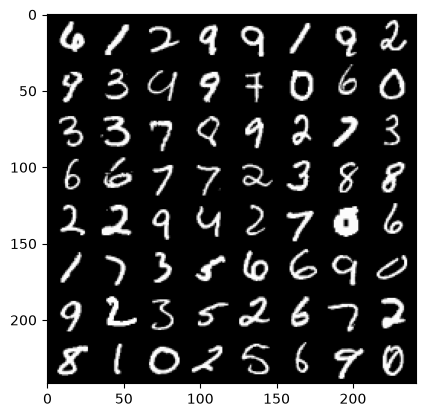

In [18]:
import matplotlib.pyplot as plt
import numpy as np
# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
# get some random training images
data_iter = iter(trainloader)
images, labels = next(data_iter)
# show images
imshow(torchvision.utils.make_grid(images))

Model

In [19]:
N_STEPS=28
N_INPUTS=28
N_NEURONS=150
N_OUTPUTS=10
N_EPOCHS=10

In [27]:
class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()

        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)

        self.FC = nn.Linear(self.n_neurons, self.n_outputs)

    def init_hidden(self,):
        # (num_layers, batch_size, n_neurons)
        return (torch.zeros(1, self.batch_size, self.n_neurons))

    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2)
        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()
        # lstm_out => n_steps, batch_size, n_neurons (hidden states for each time step)
        # self.hidden => 1, batch_size, n_neurons (final state from each lstm_out)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)
        out = self.FC(self.hidden)
        return out.view(-1, self.n_outputs) # batch_size X n_output

In [28]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
model = ImageRNN(BATCH, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(images.view(-1, 28,28))
print(logits[0:10])

tensor([[-0.0333, -0.0690, -0.1248,  0.1073,  0.0341,  0.0840,  0.0612, -0.0622,
         -0.0238, -0.0081],
        [-0.0386, -0.0527, -0.1370,  0.1184,  0.0547,  0.0863,  0.0439, -0.0683,
         -0.0230, -0.0098],
        [-0.0374, -0.0514, -0.1342,  0.1161,  0.0521,  0.0864,  0.0408, -0.0652,
         -0.0234, -0.0072],
        [-0.0404, -0.0406, -0.1402,  0.0945,  0.0549,  0.0881,  0.0185, -0.0674,
         -0.0384, -0.0327],
        [-0.0353, -0.0490, -0.1371,  0.1089,  0.0536,  0.0853,  0.0348, -0.0691,
         -0.0210, -0.0153],
        [-0.0342, -0.0441, -0.1349,  0.1033,  0.0547,  0.0837,  0.0355, -0.0696,
         -0.0271, -0.0181],
        [-0.0639, -0.0572, -0.1435,  0.0921,  0.0518,  0.0793,  0.0346, -0.0520,
         -0.0572, -0.0420],
        [-0.0339, -0.0512, -0.1341,  0.1170,  0.0540,  0.0866,  0.0430, -0.0613,
         -0.0245, -0.0122],
        [-0.0392, -0.0531, -0.1370,  0.1174,  0.0556,  0.0862,  0.0444, -0.0680,
         -0.0240, -0.0108],
        [-0.0532, -

In [29]:
import torch.optim as optim
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Model instance
model = ImageRNN(BATCH, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [ ]:
for epoch in range(N_EPOCHS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        # reset hidden states
        model.hidden = model.init_hidden()
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)
        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH)
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 0.7482 | Train Accuracy: 75.31
Epoch:  1 | Loss: 0.3223 | Train Accuracy: 90.58
Epoch:  2 | Loss: 0.2382 | Train Accuracy: 93.14
Epoch:  3 | Loss: 0.2013 | Train Accuracy: 94.29
Epoch:  4 | Loss: 0.1750 | Train Accuracy: 95.01
Epoch:  5 | Loss: 0.1575 | Train Accuracy: 95.56
Epoch:  6 | Loss: 0.1481 | Train Accuracy: 95.84
Epoch:  7 | Loss: 0.1322 | Train Accuracy: 96.27
Epoch:  8 | Loss: 0.1269 | Train Accuracy: 96.45
Epoch:  9 | Loss: 0.1182 | Train Accuracy: 96.74
